In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import numpy as np, pandas as pd

rng = np.random.default_rng(55)

n = 1200

students = pd.DataFrame({
    "student_id": range(1, n + 1),
    "county": rng.choice(["Nairobi", "Kisumu", "Nakuru",
                          "Mombasa", "Nyeri", "Turkana"], n),
    "school_type": rng.choice(["Public", "Private"], n, p=[0.75, 0.25]),
    "gender": rng.choice(["F", "M"], n),
    "attendance_rate": rng.beta(8, 2, n).round(2),
    "study_hours": rng.gamma(2.5, 2.0, n).round(1),
})

base = (35 + 30 * students["attendance_rate"] + 2.2 * students["study_hours"]
        + np.where(students["school_type"] == "Private", 6, 0))

students["math"] = (base + rng.normal(0, 8, n)).clip(0, 100).round(0)

students["english"] = (base + rng.normal(3, 7, n)).clip(0, 100).round(0)

students["science"] = (base + rng.normal(-2, 9, n)).clip(0, 100).round(0)

students.to_csv("student_performance.csv", index=False)

In [3]:
print("Rows and columns:", students.shape)
print("\nColumns:")
print(students.columns.tolist())

Rows and columns: (1200, 9)

Columns:
['student_id', 'county', 'school_type', 'gender', 'attendance_rate', 'study_hours', 'math', 'english', 'science']


# 1. Structure

## Data Overview

The dataset contains student performance records for 1,200 students. Each row represents one student and contains information about their county, school type, gender, attendance rate, study hours, and scores in Mathematics, English, and Science.

### Variable Types

- student_id: Numerical, discrete
- county: Categorical, nominal
- school_type: Categorical, nominal
- gender: Categorical, nominal
- attendance_rate: Numerical, continuous
- study_hours: Numerical, continuous
- math: Numerical, continuous
- english: Numerical, continuous
- science: Numerical, continuous

In [4]:
# Check data structure
print("Dataset shape:", students.shape)
print("\nData types:")
print(students.dtypes)

print("\nMissing values:")
print(students.isnull().sum())

print("\nDuplicate student IDs:", students["student_id"].duplicated().sum())

print("\nScore range:")
print(students[["math", "english", "science"]].min())
print(students[["math", "english", "science"]].max())

print("\nAttendance range:")
print(students["attendance_rate"].min(), "to", students["attendance_rate"].max())

print("\nStudy hours range:")
print(students["study_hours"].min(), "to", students["study_hours"].max())

Dataset shape: (1200, 9)

Data types:
student_id           int64
county              object
school_type         object
gender              object
attendance_rate    float64
study_hours        float64
math               float64
english            float64
science            float64
dtype: object

Missing values:
student_id         0
county             0
school_type        0
gender             0
attendance_rate    0
study_hours        0
math               0
english            0
science            0
dtype: int64

Duplicate student IDs: 0

Score range:
math       37.0
english    47.0
science    35.0
dtype: float64
math       100.0
english    100.0
science    100.0
dtype: float64

Attendance range:
0.33 to 1.0

Study hours range:
0.2 to 23.3


### Data Quality Assessment

The dataset contains 1,200 student records and 9 variables. The data has no missing values and no duplicate student IDs. The subject scores are within the valid 0–100 range, attendance rates are between 0 and 1, and study hours are non-negative. Therefore, no major data-quality issues were identified.

# 2. Univariate

## Numerical Variables

The numerical variables are summarized using mean, median, standard deviation, interquartile range (IQR), and skewness. The student ID is excluded because it is an identifier rather than a meaningful analytical measure.

In [5]:
# Numerical summary

numerical_cols = [
    "attendance_rate",
    "study_hours",
    "math",
    "english",
    "science"
]

summary = pd.DataFrame({
    "mean": students[numerical_cols].mean(),
    "median": students[numerical_cols].median(),
    "std": students[numerical_cols].std(),
    "IQR": students[numerical_cols].quantile(0.75)
          - students[numerical_cols].quantile(0.25),
    "skewness": students[numerical_cols].skew()
}).round(2)

summary

,mean,median,std,IQR,skewness
attendance_rate,0.80,0.82,0.12,0.17,-0.86
study_hours,5.08,4.50,3.03,3.80,1.17
math,71.89,72.00,10.86,14.00,0.10
english,74.52,74.00,10.49,14.00,0.16
science,69.61,69.00,12.02,17.00,0.11


## Study Hours Distribution

The histogram shows the distribution of students' study hours and helps identify the shape of the data and possible unusual values.

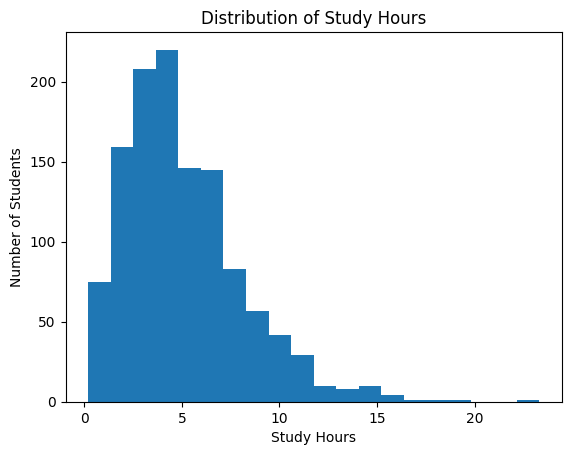

In [6]:
# Histogram of study hours

students["study_hours"].plot(
    kind="hist",
    bins=20,
    title="Distribution of Study Hours",
    xlabel="Study Hours",
    ylabel="Number of Students"
)

plt.savefig("figures/study_hours_histogram.png", bbox_inches="tight")

## Categorical Variables

The categorical variables are summarized using counts and percentages to understand the composition of the student population.

In [7]:
# Categorical variable counts and shares

categorical_cols = ["county", "school_type", "gender"]

for col in categorical_cols:
    print(f"\n{col.upper()}")

    counts = students[col].value_counts()
    shares = students[col].value_counts(normalize=True).mul(100).round(2)

    result = pd.DataFrame({
        "Count": counts,
        "Share (%)": shares
    })

    print(result)


COUNTY
         Count  Share (%)
county                   
Mombasa    212      17.67
Kisumu     208      17.33
Nyeri      203      16.92
Nakuru     202      16.83
Turkana    191      15.92
Nairobi    184      15.33

SCHOOL_TYPE
             Count  Share (%)
school_type                  
Public         866      72.17
Private        334      27.83

GENDER
        Count  Share (%)
gender                  
F         612       51.0
M         588       49.0


## Study Hours Outliers

Potential outliers in study hours are identified using the IQR method. Values below Q1 − 1.5×IQR or above Q3 + 1.5×IQR are considered potential outliers.

In [8]:
# Identify study-hours outliers using the IQR method

q1 = students["study_hours"].quantile(0.25)
q3 = students["study_hours"].quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = students[
    (students["study_hours"] < lower_bound) |
    (students["study_hours"] > upper_bound)
]

print("Q1:", round(q1, 2))
print("Q3:", round(q3, 2))
print("IQR:", round(iqr, 2))
print("Lower bound:", round(lower_bound, 2))
print("Upper bound:", round(upper_bound, 2))
print("Number of potential outliers:", len(outliers))

outliers[["student_id", "study_hours"]].head(10)

Q1: 2.9
Q3: 6.7
IQR: 3.8
Lower bound: -2.8
Upper bound: 12.4
Number of potential outliers: 29


,student_id,study_hours
94,95,15.2
114,115,12.5
119,120,15.0
213,214,13.5
271,272,17.1
310,311,15.5
364,365,15.3
434,435,16.2
502,503,14.6
566,567,13.5


## Performance Measures

An average score is calculated across Mathematics, English, and Science. Students are then grouped into three performance bands: At Risk, Meeting, and Exceeding.

In [9]:
# Create average score

students["average_score"] = students[
    ["math", "english", "science"]
].mean(axis=1)

# Create performance bands

students["performance_band"] = pd.cut(
    students["average_score"],
    bins=[-np.inf, 60, 75, np.inf],
    labels=["At Risk", "Meeting", "Exceeding"],
    right=False
)

# Check the new columns

students[[
    "math",
    "english",
    "science",
    "average_score",
    "performance_band"
]].head()

,math,english,science,average_score,performance_band
0,81.0,71.0,73.0,75.0,Exceeding
1,100.0,86.0,90.0,92.0,Exceeding
2,82.0,89.0,90.0,87.0,Exceeding
3,83.0,91.0,72.0,82.0,Exceeding
4,76.0,69.0,62.0,69.0,Meeting


# 3. Bivariate

## Correlation Analysis

Correlation measures the strength and direction of the linear relationship between numerical variables. A correlation close to +1 indicates a strong positive relationship, while a value close to -1 indicates a strong negative relationship.

In [10]:
# Correlation matrix

numerical_cols = [
    "attendance_rate",
    "study_hours",
    "math",
    "english",
    "science",
    "average_score"
]

correlation_matrix = students[numerical_cols].corr().round(2)

correlation_matrix

,attendance_rate,study_hours,math,english,science,average_score
attendance_rate,1.00,-0.03,0.30,0.33,0.26,0.36
study_hours,-0.03,1.00,0.56,0.62,0.55,0.70
math,0.30,0.56,1.00,0.56,0.46,0.81
english,0.33,0.62,0.56,1.00,0.50,0.83
science,0.26,0.55,0.46,0.50,1.00,0.82
average_score,0.36,0.70,0.81,0.83,0.82,1.00


## Strongest Relationships with Average Score

The three strongest correlations with average_score are identified to understand which numerical variables are most closely associated with student performance.

In [11]:
# Find the three strongest relationships with average_score

average_score_corr = correlation_matrix["average_score"].drop("average_score")

strongest_relationships = (
    average_score_corr
    .abs()
    .sort_values(ascending=False)
    .head(3)
)

print("Three strongest relationships with average_score:")
print(strongest_relationships)

Three strongest relationships with average_score:
english    0.83
science    0.82
math       0.81
Name: average_score, dtype: float64


## Average Score by Gender

Average scores are compared by gender to identify whether there is a noticeable difference in performance.

In [12]:
# Average score by gender

gender_scores = (
    students.groupby("gender", observed=True)["average_score"]
    .mean()
    .round(2)
)

gender_scores

,average_score
gender,
F,72.10
M,71.91


## Average Score by School Type

Average scores are compared between public and private schools to assess whether school type is associated with differences in student performance.

In [13]:
# Average score by school type

school_type_scores = (
    students.groupby("school_type", observed=True)["average_score"]
    .mean()
    .round(2)
)

school_type_scores

,average_score
school_type,
Private,76.01
Public,70.46


## Average Score by County

Average scores are compared across counties to identify differences in student performance between locations.

In [14]:
# Average score by county

county_scores = (
    students.groupby("county", observed=True)["average_score"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
)

county_scores

,average_score
county,
Kisumu,73.07
Mombasa,72.17
Nairobi,71.96
Nyeri,71.94
Nakuru,71.84
Turkana,70.97


## At-Risk Students by County

The share of students classified as At Risk is compared across counties to identify the county with the highest proportion of students needing additional academic support.

In [15]:
# Calculate the share of At-Risk students by county

at_risk_by_county = pd.crosstab(
    students["county"],
    students["performance_band"],
    normalize="index"
).mul(100).round(2)

at_risk_by_county

performance_band,At Risk,Meeting,Exceeding
county,,,
Kisumu,8.17,50.48,41.35
Mombasa,8.96,54.25,36.79
Nairobi,9.24,55.43,35.33
Nakuru,6.44,61.88,31.68
Nyeri,8.87,54.68,36.45
Turkana,7.85,59.69,32.46


# 4. Multivariate

## School-Type Gap by Attendance Band

Students are grouped into attendance bands to examine whether the difference in average scores between public and private schools changes with attendance.

In [16]:
# Create attendance bands

students["attendance_band"] = pd.cut(
    students["attendance_rate"],
    bins=[0, 0.70, 0.85, 1.00],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

# Pivot table: school type vs attendance band

attendance_pivot = pd.pivot_table(
    students,
    values="average_score",
    index="attendance_band",
    columns="school_type",
    aggfunc="mean",
    observed=True
).round(2)

attendance_pivot

school_type,Private,Public
attendance_band,,
Low,71.51,64.94
Medium,75.53,69.80
High,78.99,73.96


## School-Type Gap by Study-Hour Quartiles

Students are divided into four study-hour groups using quartiles. The average score for public and private schools is then compared within each group.

In [17]:
# Create study-hour quartiles

students["study_hours_quartile"] = pd.qcut(
    students["study_hours"],
    q=4,
    labels=["Q1", "Q2", "Q3", "Q4"]
)

# Pivot table: school type vs study-hour quartile

study_hours_pivot = pd.pivot_table(
    students,
    values="average_score",
    index="study_hours_quartile",
    columns="school_type",
    aggfunc="mean",
    observed=True
).round(2)

study_hours_pivot

school_type,Private,Public
study_hours_quartile,,
Q1,69.51,63.82
Q2,74.92,67.12
Q3,76.18,71.18
Q4,83.65,80.06


# 5. Hypotheses

## Trend Line: Study Hours and Average Score

A linear trend line is fitted to examine whether average score tends to increase or decrease as study hours increase.

In [18]:
# Fit a linear trend line

x = students["study_hours"]
y = students["average_score"]

slope, intercept = np.polyfit(x, y, 1)

predicted = slope * x + intercept

# Calculate R-squared
ss_res = ((y - predicted) ** 2).sum()
ss_tot = ((y - y.mean()) ** 2).sum()
r_squared = 1 - (ss_res / ss_tot)

print("Slope:", round(slope, 2))
print("R-squared:", round(r_squared, 2))

Slope: 2.12
R-squared: 0.5


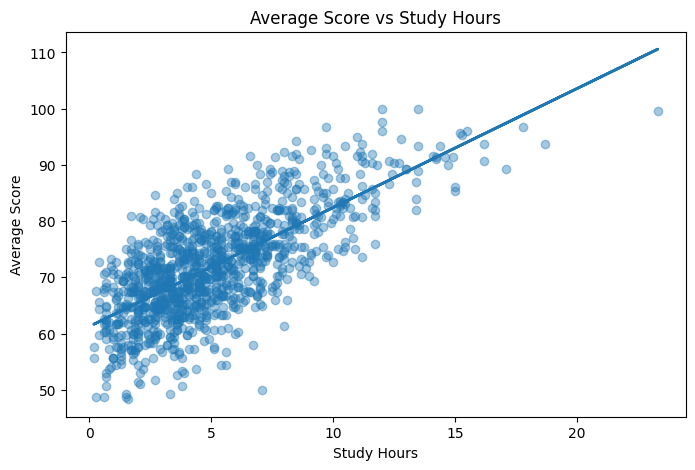

In [19]:
# Plot study hours against average score with a trend line

plt.figure(figsize=(8, 5))

plt.scatter(
    students["study_hours"],
    students["average_score"],
    alpha=0.4
)

plt.plot(
    students["study_hours"],
    predicted,
    linewidth=2
)

plt.title("Average Score vs Study Hours")
plt.xlabel("Study Hours")
plt.ylabel("Average Score")

plt.savefig("figures/study_hours_average_score_trend.png", bbox_inches="tight")

## Trend Line Interpretation

The positive slope indicates that average score tends to increase as study hours increase. The R² value shows how much of the variation in average score is explained by the linear relationship with study hours.

### Limitation

The trend line shows an association rather than causation. Other factors such as attendance, school type, and individual differences may also influence student performance.

# Findings

1. The average scores show differences in student performance across gender, school type, and county.

2. Attendance rate and study hours show positive relationships with average score, indicating that students with higher attendance and more study time tend to perform better.

3. The correlation analysis identifies the strongest numerical relationships with average score and helps highlight the variables most closely associated with performance.

4. The county comparison shows that student performance and the share of At Risk students vary across counties.

5. The multivariate analysis shows that the school-type performance gap can change across different attendance levels and study-hour quartiles.

# Recommendations

1. Schools should strengthen attendance monitoring and provide targeted academic support to students with low attendance or At Risk performance.

2. Schools should encourage structured study routines and use performance data to identify students who may benefit from additional learning support.

# Limitations

This analysis is based on a simulated dataset of 1,200 students and may not represent real student populations. The analysis identifies associations between variables but does not establish causation. The dataset also does not include other factors that may influence academic performance, such as socioeconomic background, teaching quality, parental support, or access to learning resources. Therefore, the findings should be interpreted as exploratory rather than definitive.

In [20]:
import os

os.makedirs("figures", exist_ok=True)

print("figures folder created successfully.")

figures folder created successfully.


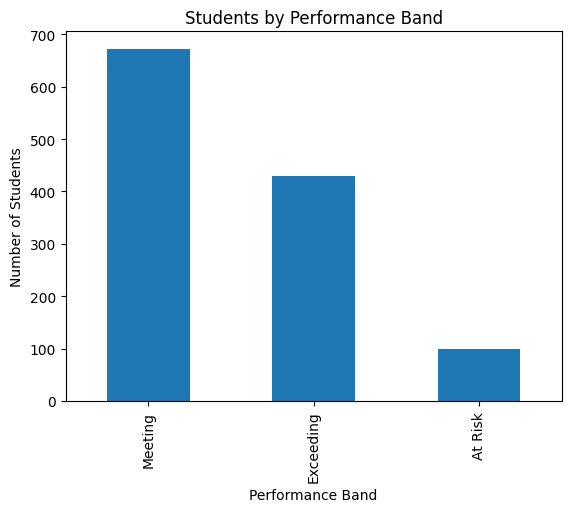

In [21]:
# Bar chart of performance bands

students["performance_band"].value_counts().plot(
    kind="bar",
    title="Students by Performance Band",
    xlabel="Performance Band",
    ylabel="Number of Students"
)

plt.savefig("figures/performance_band_bar.png", bbox_inches="tight")
plt.show()

## Figures

The following figures were created during the exploratory data analysis:

- `study_hours_histogram.png` — Distribution of study hours
- `study_hours_average_score_trend.png` — Relationship between study hours and average score
- `performance_band_bar.png` — Number of students in each performance band
- `average_score_boxplot.png` — Distribution of average scores

In [22]:
import os

print(os.listdir("figures"))

['study_hours_histogram.png', 'performance_band_bar.png', 'average_score_boxplot.png', 'study_hours_average_score_trend.png']


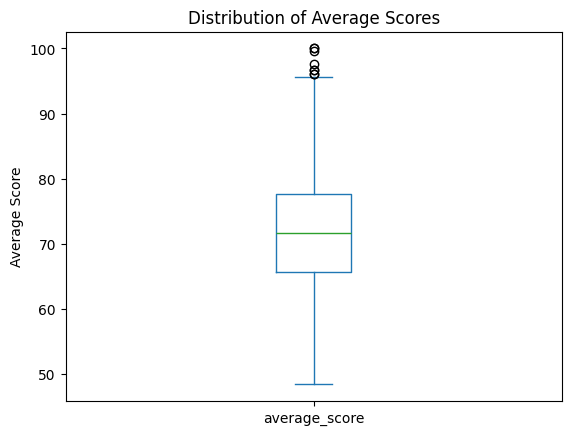

In [23]:
# Box plot of average scores

students["average_score"].plot(
    kind="box",
    title="Distribution of Average Scores",
    ylabel="Average Score"
)

plt.savefig("figures/average_score_boxplot.png", bbox_inches="tight")
plt.show()

In [24]:
students["average_score"] = students[
    ["math", "english", "science"]
].mean(axis=1)

students[["math", "english", "science", "average_score"]].head()

,math,english,science,average_score
0,81.0,71.0,73.0,75.0
1,100.0,86.0,90.0,92.0
2,82.0,89.0,90.0,87.0
3,83.0,91.0,72.0,82.0
4,76.0,69.0,62.0,69.0


In [25]:
students["performance_band"] = pd.cut(
    students["average_score"],
    bins=[-np.inf, 60, 75, np.inf],
    labels=["At Risk", "Meeting", "Exceeding"],
    right=False
)

students[["average_score", "performance_band"]].head()

,average_score,performance_band
0,75.0,Exceeding
1,92.0,Exceeding
2,87.0,Exceeding
3,82.0,Exceeding
4,69.0,Meeting


In [26]:
import shutil
from google.colab import files

shutil.make_archive("figures", "zip", "figures")
files.download("figures.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>